# IndieGuard: Review 1
Predicting negative-review risk and winning feature combinations for indie games on Steam.

Reads the committed data and results; the heavy model runs live in `src/models/`. Runs in under a minute.

## 1. Problem
Steam refunds a game within 14 days if the player has under 2 hours of playtime, so an early negative review can cost a small studio
the sale as well as the rating. We want to tell a studio what to fix before the refund window closes, what to build, and when to patch.

Two tasks: **review level** (will this review be negative?) and **game level** (which success tier will the game land in?).

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
PROC, FEAT, RES, DOCS = ROOT / "data/processed", ROOT / "data/processed/features", ROOT / "reports/results", ROOT / "docs"
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:,.3f}".format

## 2. Data

In [2]:
games = pd.read_parquet(PROC / "games_clean.parquet")
reviews = pd.read_parquet(PROC / "reviews_clean", columns=["appid", "voted_up", "language", "created"])
events = pd.read_parquet(PROC / "events.parquet")

print(f"{len(games):,} games | {len(reviews):,} reviews | {len(events):,} patch and sale announcements")
print(f"negative reviews {(~reviews.voted_up).mean():.1%} | English {reviews.language.eq('english').mean():.1%} | {reviews.language.nunique()} languages")
games.release_date.dt.year.value_counts().sort_index().to_frame("games").T

1,861 games | 1,648,387 reviews | 29,918 patch and sale announcements
negative reviews 10.4% | English 39.5% | 31 languages


release_date,2022,2023,2024,2025
games,286,372,557,646


In [3]:
reviews.groupby("appid").size().describe(percentiles=[.5, .9, .99]).astype(int).to_frame("reviews per game").T

,count,mean,std,min,50%,90%,99%,max
reviews per game,1861,885,6065,10,50,1005,15763,162452


Very uneven: a few huge games hold most of the reviews. That is why model results later are also reported per game.

## 3. Cleaning

In [4]:
log = pd.DataFrame(json.load(open(PROC / "cleaning_log.json")))
log[log.affected > 0][["table", "action", "rule", "affected"]].reset_index(drop=True)

,table,action,rule,affected
0,games,fix,launch_date = original launch (Early Access st...,318
1,games,flag,Early Access launch before 2022 (1.0 inside wi...,86
2,games,fix,Strip whitespace in tag/genre/developer lists,56
3,games,flag,Review scrape < 99% of Steam total,22
4,games,flag,"Reviews capped (newest 15,000 only)",5
5,news,flag,Developer announcement (not press coverage),44232
6,news,flag,Patch event,28875
7,news,flag,Sale/discount event,1043
8,reviews,drop,Empty review text,4612
9,reviews,flag,Playtime at review above 99.5% quantile (363 h...,8242


Only unusable rows are dropped (4,612 empty reviews). Everything suspicious is flagged and kept, so each analysis picks what it needs,
e.g. `text_mining_ok` for text. Full log: `docs/cleaning_log.md`.

## 4. EDA

14.5% of 1,490 games have 30%+ negative reviews


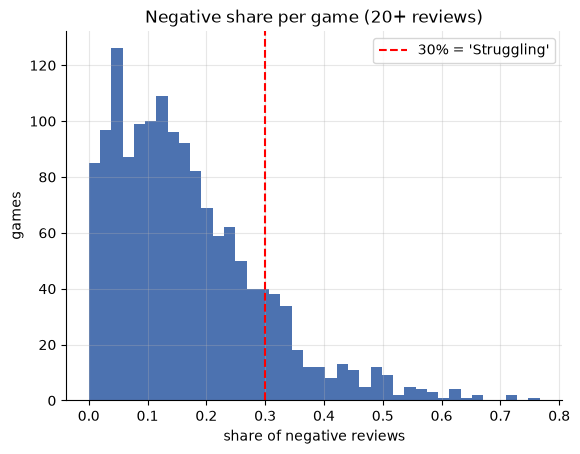

In [5]:
g = games[games.steam_total_reviews >= 20].copy()
g["neg_ratio"] = g.steam_total_negative / g.steam_total_reviews

ax = g.neg_ratio.hist(bins=40, color="#4C72B0")
ax.axvline(.30, c="r", ls="--", label="30% = 'Struggling'")
ax.set(xlabel="share of negative reviews", ylabel="games", title="Negative share per game (20+ reviews)")
ax.legend()
print(f"{(g.neg_ratio >= .30).mean():.1%} of {len(g):,} games have 30%+ negative reviews")

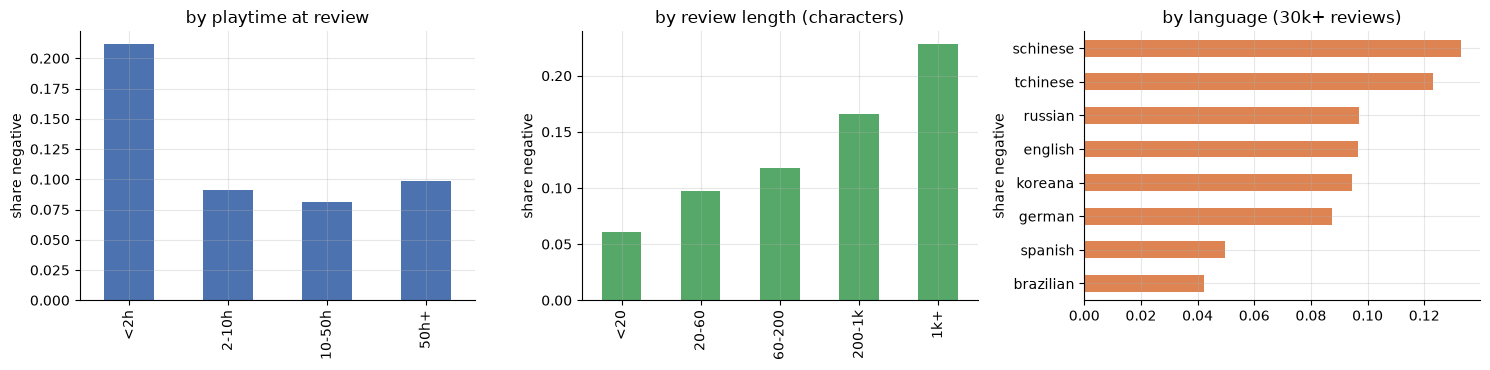

In [6]:
cols = ["target_is_negative", "playtime_bucket", "in_refund_window", "price_tier", "review_n_chars", "language"]
rf = pd.read_parquet(FEAT / "review_features", columns=["recommendationid"] + cols)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
rf[rf.playtime_bucket >= 0].groupby("playtime_bucket").target_is_negative.mean().rename({0: "<2h", 1: "2-10h", 2: "10-50h", 3: "50h+"}).plot.bar(ax=ax[0], color="#4C72B0", title="by playtime at review")
rf.groupby(pd.cut(rf.review_n_chars, [0, 20, 60, 200, 1000, 1e9], labels=["<20", "20-60", "60-200", "200-1k", "1k+"]), observed=True).target_is_negative.mean().plot.bar(ax=ax[1], color="#55A868", title="by review length (characters)")
rf.groupby("language").target_is_negative.agg(["mean", "size"]).query("size > 30000")["mean"].sort_values().plot.barh(ax=ax[2], color="#DD8452", title="by language (30k+ reviews)")
for a in ax: a.set_xlabel(""); a.set_ylabel("share negative")
plt.tight_layout()

Short playtime and long reviews go with negativity, and languages differ a lot. Playtime under 2 hours stands out: 21% negative against about 9% for everyone else.

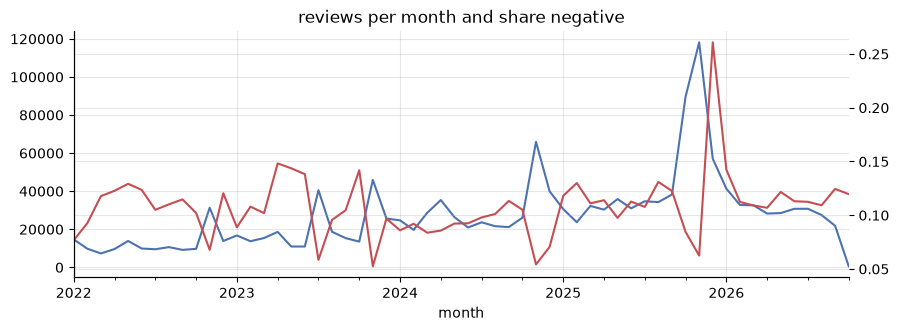

In [7]:
m = reviews.assign(month=reviews.created.dt.tz_localize(None).dt.to_period("M"), neg=~reviews.voted_up).groupby("month").agg(n=("neg", "size"), neg=("neg", "mean"))
m = m[m.index >= "2022-01"]
ax = m.n.plot(color="#4C72B0", figsize=(10, 3.2), title="reviews per month and share negative")
m.neg.plot(ax=ax.twinx(), color="#C44E52");

Review volume depends on how well games are doing, so it is an outcome, not something a studio can use to predict reception.
More EDA (29 figures, association tests): `notebooks/02_EDA_Visualizations.ipynb`.

## 5. Features and dimensionality reduction

In [8]:
cat = pd.read_csv(DOCS / "feature_engineering/feature_catalog.csv")
cat.groupby(["table", "group"]).size().rename("entries").reset_index()

,table,group,entries
0,game_features,key,1
1,game_features,launch_time,17
2,game_features,post_launch,3
3,game_outcomes,outcome,1
4,game_targets,key,1
5,game_targets,target,2
6,review_features,at_review,16
7,review_features,key,1
8,review_features,target,1
9,text_svd,at_review,1


k = 68 keeps 75.3% of the training variance
pc_01 + ['Action', 'Action Roguelike', 'Bullet Hell', 'Full controller support'] | - ['Strategy', 'Deckbuilding', 'Card Game', 'Card Battler']
pc_02 + ['Steam Cloud', 'Full controller support', 'Steam Achievements', 'DualShock Controller Support'] | - ['3D', 'Free to Play', 'Casual', 'Combat']
pc_03 + ['2D', 'Pixel Graphics', 'Casual', 'Bullet Hell'] | - ['3D', 'Adventure', 'Multi-player', 'RPG']


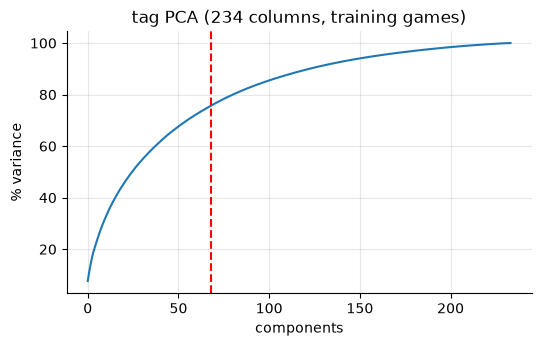

In [9]:
v = pd.read_csv(DOCS / "feature_engineering/tag_pca_variance.csv")
k = 68                                           # elbow of the cumulative variance curve
ax = (v.cumulative * 100).plot(figsize=(6, 3.4), xlabel="components", ylabel="% variance", title="tag PCA (234 columns, training games)")
ax.axvline(k, c="r", ls="--")
print(f"k = {k} keeps {v.cumulative[k - 1]:.1%} of the training variance")

L = pd.read_csv(DOCS / "feature_engineering/tag_pca_loadings.csv", index_col=0)
L.index = L.index.str.split("__").str[1]
for pc in ["pc_01", "pc_02", "pc_03"]:
    s = L[pc].sort_values()
    print(pc, "+", list(s.index[::-1][:4]), "| -", list(s.index[:4]))

Tags and store categories (439 columns) are filtered to 234 and reduced with PCA, fitted on training games only.
PC1 is action roguelike vs card/strategy, PC2 a polished store page vs 3D and free to play, PC3 2D pixel art vs 3D.
Review text goes through TF-IDF and SVD. Details: `docs/feature_engineering.md`.

## 6. Targets and split

In [10]:
t = pd.read_parquet(FEAT / "game_targets.parquet")
pd.crosstab(t.tier, t.split, margins=True)

split,test,train,All
tier,,,
Solid,147,605,752
Strong,101,421,522
Struggling,51,165,216
All,299,1191,1490


Struggling is 30%+ negative, Strong 10% or less, Solid in between; games under 20 reviews get no tier.
The split is by game (80/20, plus 5 cross-validation folds inside train), so a game never appears on both sides.

## 7. Models

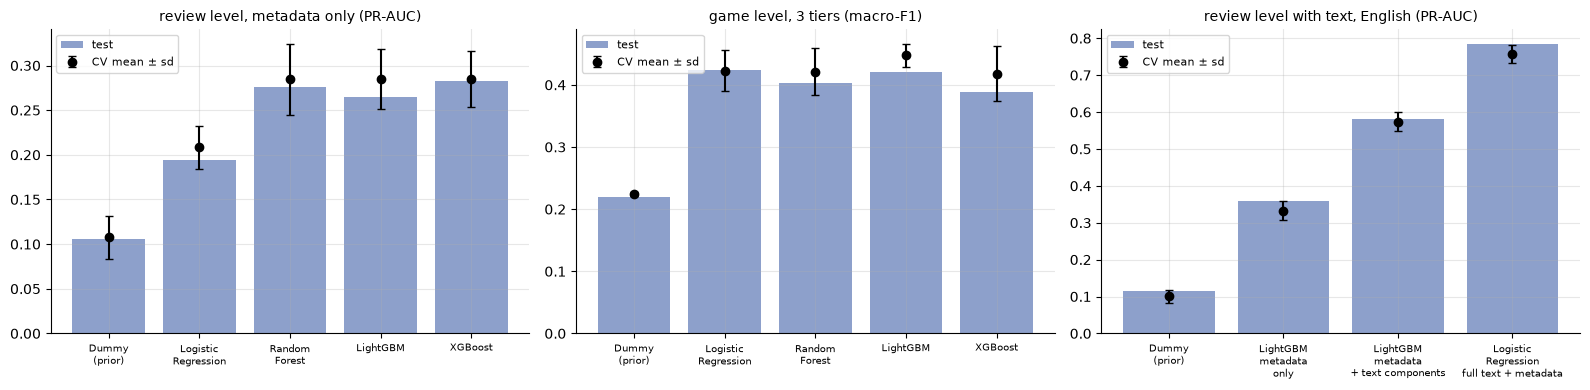

In [11]:
rev, gm, txt = (pd.read_csv(RES / f).set_index("Model") for f in ["comparison_review.csv", "comparison_game.csv", "comparison_review_text.csv"])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, d, title in zip(ax, [rev, gm, txt], ["review level, metadata only (PR-AUC)", "game level, 3 tiers (macro-F1)", "review level with text, English (PR-AUC)"]):
    a.bar(range(len(d)), d.Test, color="#8da0cb", label="test")
    a.errorbar(range(len(d)), d["CV mean"], yerr=d["CV sd"], fmt="ko", capsize=3, label="CV mean ± sd")
    a.set_xticks(range(len(d)), [n.replace(", ", "\n").replace(" ", "\n", 1) for n in d.index], fontsize=7)
    a.set_title(title, fontsize=10); a.legend(fontsize=8)
plt.tight_layout()

In [12]:
print("review level (guessing: PR-AUC 0.106)")
display(rev[["CV mean", "Test", "Test ROC-AUC", "Per-game ROC-AUC"]])
print("game level (guessing: macro-F1 0.22)")
display(gm[["CV mean", "Test", "CI low", "CI high", "Recall Struggling", "Recall Solid", "Recall Strong"]])
print("review level, English, with text")
display(txt[["CV mean", "Test", "Test ROC-AUC"]])

review level (guessing: PR-AUC 0.106)


,CV mean,Test,Test ROC-AUC,Per-game ROC-AUC
Model,,,,
Dummy (prior),0.107,0.106,0.500,0.500
Logistic Regression,0.208,0.194,0.663,0.684
Random Forest,0.285,0.275,0.721,0.745
LightGBM,0.285,0.265,0.729,0.744
XGBoost,0.285,0.283,0.733,0.743


game level (guessing: macro-F1 0.22)


,CV mean,Test,CI low,CI high,Recall Struggling,Recall Solid,Recall Strong
Model,,,,,,,
Dummy (prior),0.225,0.220,0.201,0.236,0.000,1.000,0.000
Logistic Regression,0.422,0.423,0.365,0.477,0.390,0.400,0.520
Random Forest,0.421,0.404,0.342,0.464,0.140,0.570,0.500
LightGBM,0.447,0.421,0.359,0.478,0.450,0.370,0.510
XGBoost,0.418,0.388,0.326,0.448,0.140,0.560,0.480


review level, English, with text


,CV mean,Test,Test ROC-AUC
Model,,,
Dummy (prior),0.101,0.115,0.500
"LightGBM, metadata only",0.332,0.360,0.758
"LightGBM, metadata + text components",0.574,0.581,0.892
"Logistic Regression, full text + metadata",0.757,0.785,0.955


- Review level: the three tree models are about equal and Logistic Regression is weaker. All beat the dummy baseline.
- Game level: all four models beat the baseline by a similar margin, simple ones included. The intervals overlap (299 test games), so no winner.
- Adding the review text is the big jump: PR-AUC 0.36 to 0.79 on the same reviews. This detects negative reviews from their own text, it does not forecast them.

## 8. Evaluation and interpretation

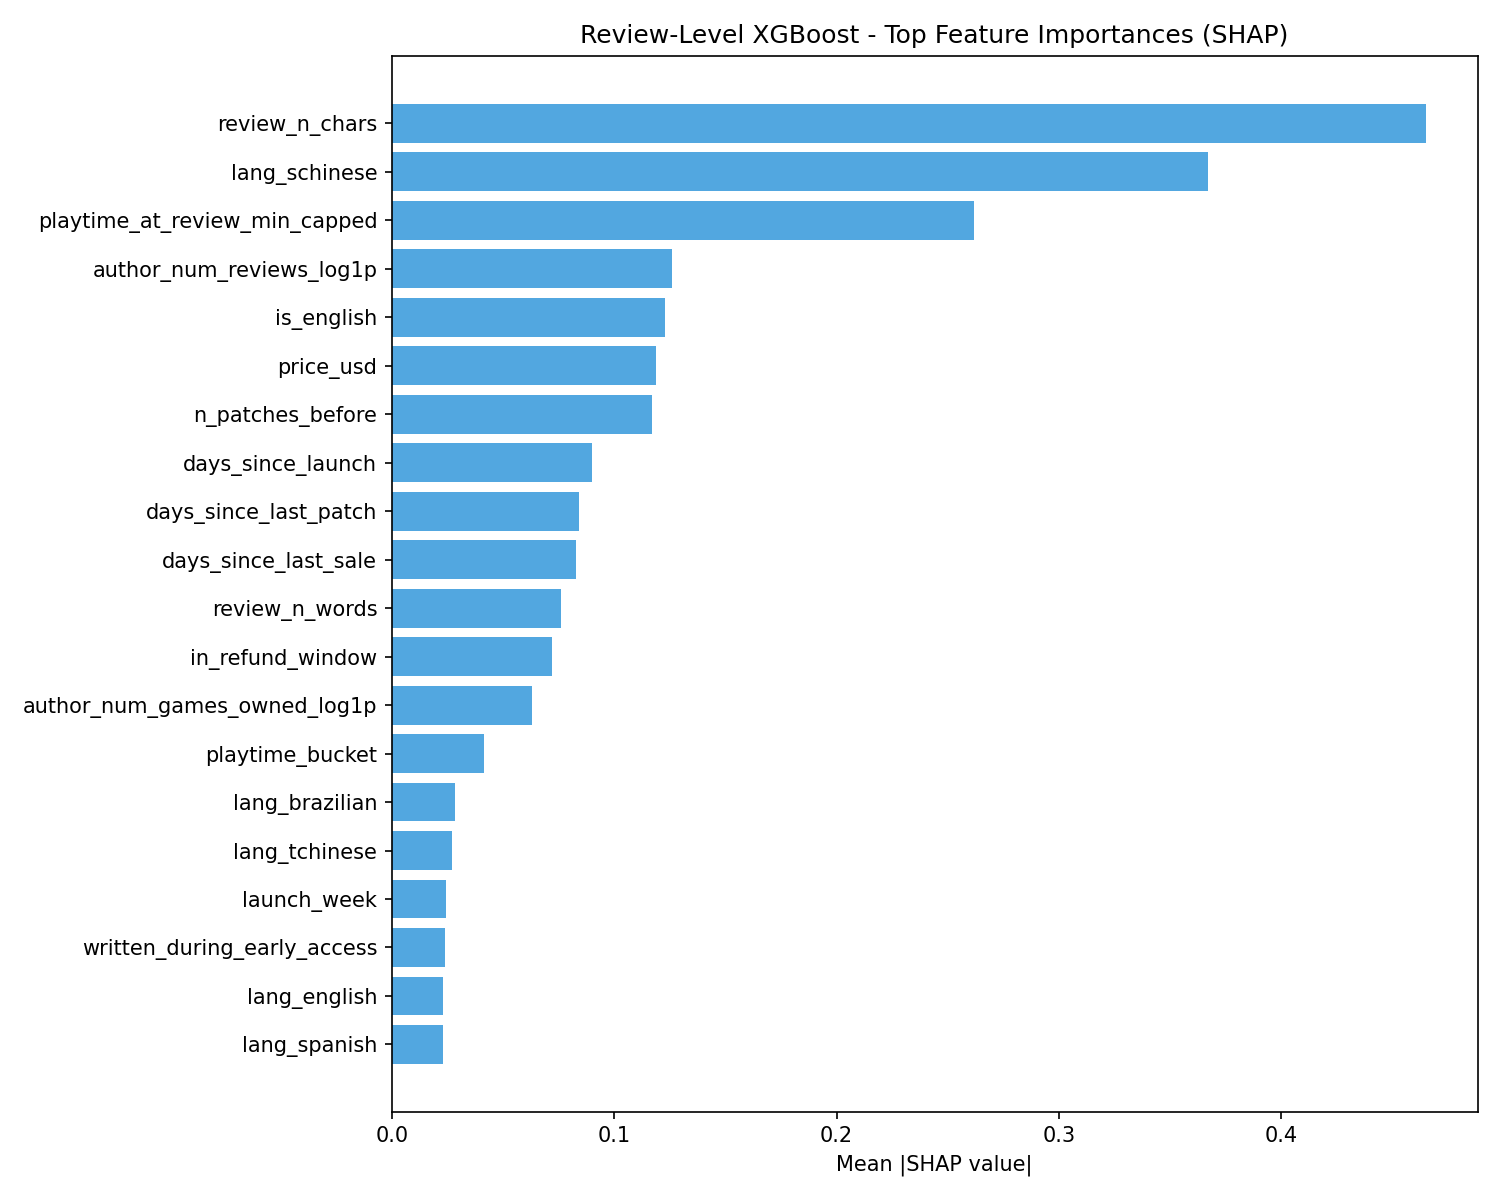

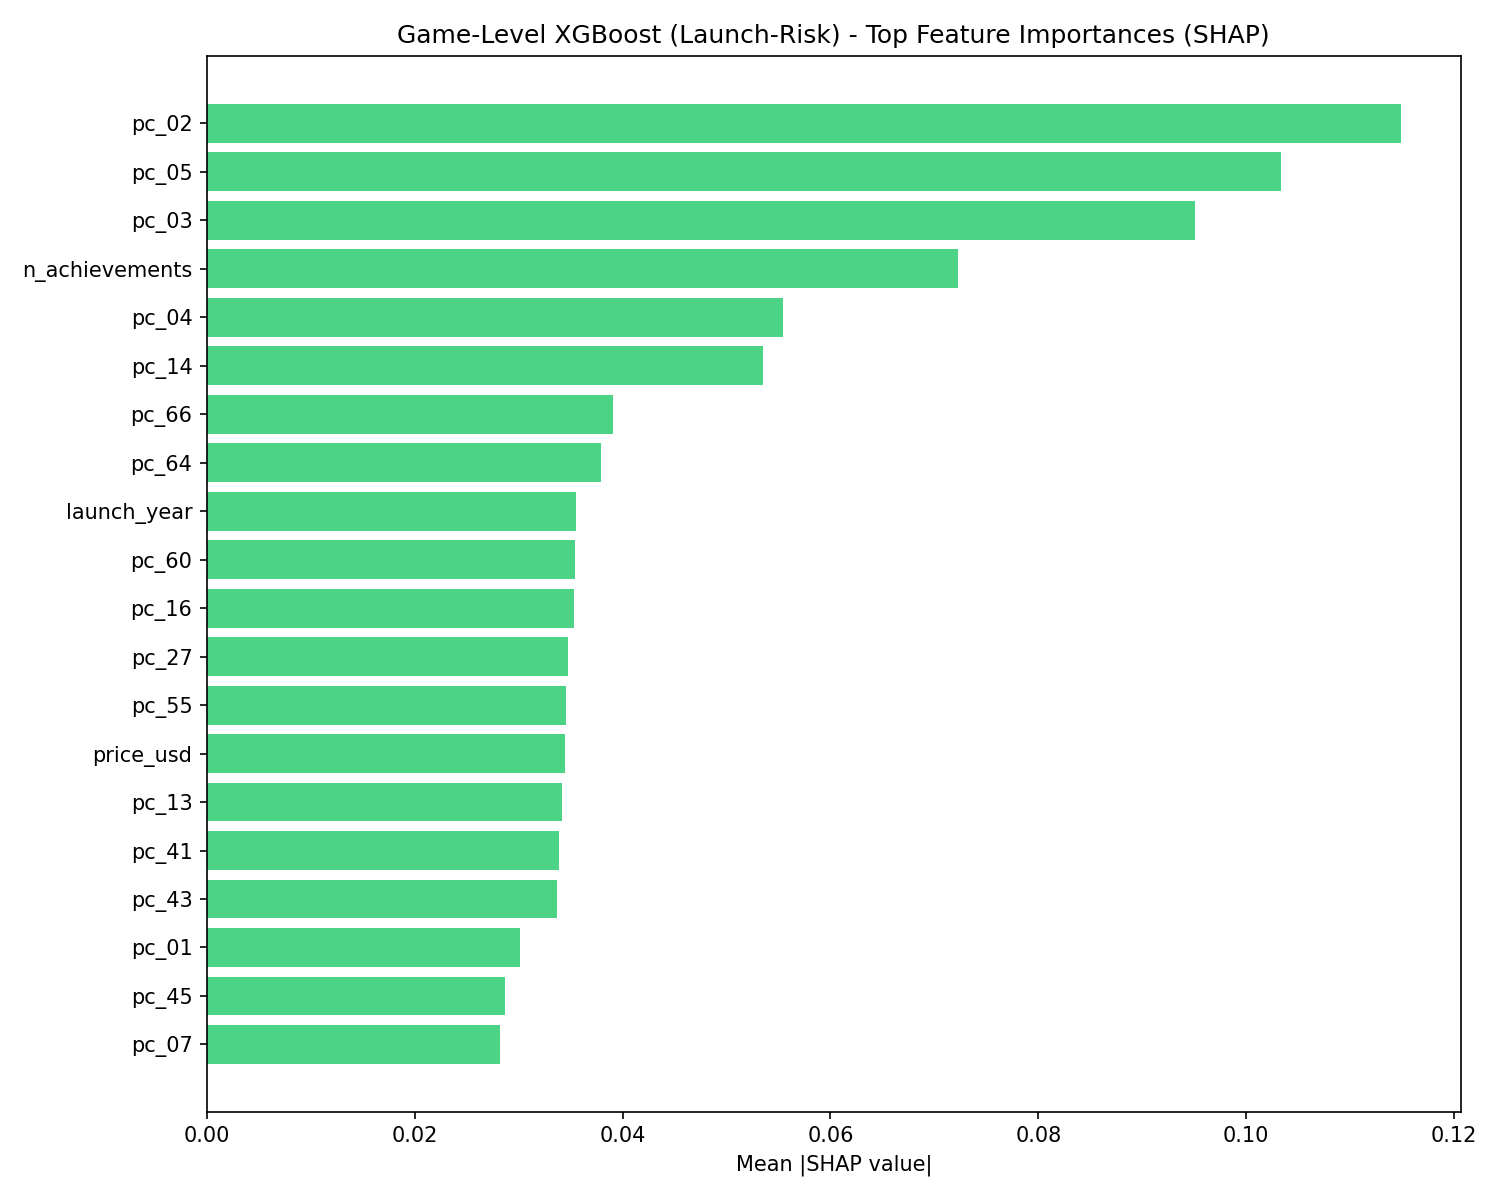

In [13]:
for f in ["review_xgb_shap_bar.png", "game_xgb_shap_bar.png"]:
    display(Image(filename=str(ROOT / "figures/models" / f), width=520))

Review level, the top features are review length, language, playtime and the reviewer's review count. Game level, they are tag components
(polished store page, roguelite and bullet hell, 2D pixel art) and the number of achievements.

Store metadata says little about how good a game is: tag components alone give macro-F1 0.41 against 0.42 for all features, and going from
238 to 952 training games moved it only from 0.409 to 0.418. More data would not help, more information would.

## 9. Business findings

refund window: 21.2% negative inside vs 8.8% outside
14.5% of reviews but 29.0% of all negative reviews are inside the window


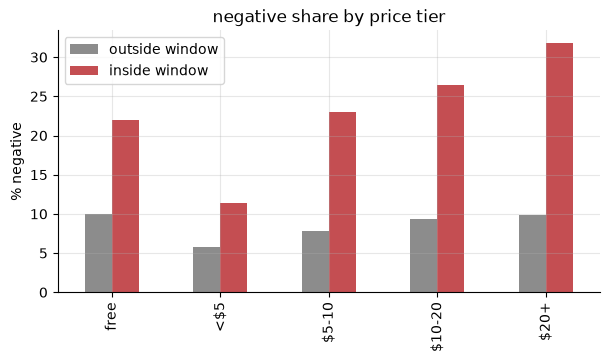

In [14]:
neg = rf.target_is_negative == 1
print(f"refund window: {rf[rf.in_refund_window == 1].target_is_negative.mean():.1%} negative inside vs {rf[rf.in_refund_window == 0].target_is_negative.mean():.1%} outside")
print(f"{rf.in_refund_window.mean():.1%} of reviews but {rf[neg].in_refund_window.mean():.1%} of all negative reviews are inside the window")

by_price = rf.groupby(["price_tier", "in_refund_window"]).target_is_negative.mean().unstack()
by_price.index, by_price.columns = ["free", "<$5", "$5-10", "$10-20", "$20+"], ["outside window", "inside window"]
by_price.mul(100).plot.bar(figsize=(7, 3.4), color=["#8C8C8C", "#C44E52"], ylabel="% negative", title="negative share by price tier");

Early negatives are common and get worse with price: inside the window 11% negative for games under $5, 32% for $20 or more.
Outside the window price makes little difference.

,negative when mentioned,in early negatives,in later negatives
"Bugs, crashes, performance",0.269,0.129,0.153
"Boring, repetitive, grindy",0.378,0.152,0.212
Price and value,0.662,0.045,0.051
"Unfair, frustrating, balance",0.310,0.079,0.175
"Controls, camera, interface",0.281,0.131,0.072
"Too little content, unfinished",0.211,0.063,0.083
"Online, servers, multiplayer",0.134,0.041,0.056
"Monetisation, ads, DLC",0.216,0.014,0.033
Refunds,0.695,0.086,0.029
Praise (control group),0.077,0.252,0.393


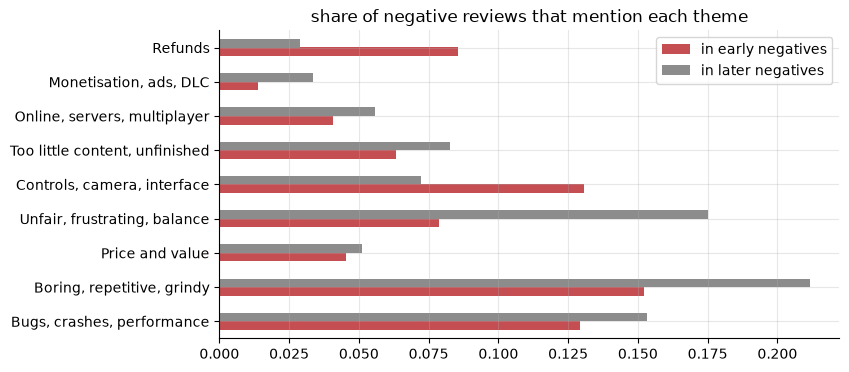

In [15]:
txt = pd.concat([pd.read_parquet(p, columns=["recommendationid", "review", "text_mining_ok"]) for p in sorted((PROC / "reviews_clean").glob("*.parquet"))])
d = txt[txt.text_mining_ok].merge(rf[["recommendationid", "target_is_negative", "in_refund_window"]], on="recommendationid")
low = d.review.str.lower()

sys.path.insert(0, str(ROOT))
from src.analysis.business_findings import THEMES as themes      # same keyword groups as docs/business_findings.md
%matplotlib inline

negs = d[d.target_is_negative == 1]
rows = {k: {"negative when mentioned": d.target_is_negative[low.str.contains(p)].mean(),
            "in early negatives": negs[negs.in_refund_window == 1].review.str.lower().str.contains(p).mean(),
            "in later negatives": negs[negs.in_refund_window == 0].review.str.lower().str.contains(p).mean()} for k, p in themes.items()}
tbl = pd.DataFrame(rows).T
tbl.drop("Praise (control group)").plot.barh(y=["in early negatives", "in later negatives"], figsize=(8, 4), color=["#C44E52", "#8C8C8C"], title="share of negative reviews that mention each theme");
tbl.round(3)

Early negatives complain more about controls, camera and interface; later ones about repetition and unfair difficulty. Bugs are mentioned
in both. Price complaints are rare but almost always negative. These are keyword groups on English reviews, an initial look until Review 2's topic modelling.

In [16]:
gf = pd.read_parquet(FEAT / "game_features.parquet").merge(t[["appid", "tier"]], on="appid")
tr = gf[(gf.split == "train") & gf.tier.notna()]                        # training games only
for col in ["n_dlc", "has_achievements", "launched_in_early_access", "controller_support_level"]:
    rate = (tr.tier == "Struggling").groupby(tr[col] > 0).agg(["mean", "size"])
    print(col, "| without:", f"{rate['mean'].iloc[0]:.1%} (n={rate['size'].iloc[0]})", "| with:", f"{rate['mean'].iloc[1]:.1%} (n={rate['size'].iloc[1]})")
for tier in ["Struggling", "Strong"]:
    print(f"share {tier} by price tier (free, <$5, $5-10, $10-20, $20+):", (tr.tier == tier).groupby(tr.price_tier).mean().round(2).tolist())

n_dlc | without: 15.9% (n=903) | with: 7.3% (n=288)
has_achievements | without: 19.6% (n=225) | with: 12.5% (n=966)
launched_in_early_access | without: 13.0% (n=955) | with: 17.4% (n=236)
controller_support_level | without: 15.5% (n=703) | with: 11.5% (n=488)
share Struggling by price tier (free, <$5, $5-10, $10-20, $20+): [0.17, 0.13, 0.13, 0.14, 0.15]
share Strong by price tier (free, <$5, $5-10, $10-20, $20+): [0.33, 0.44, 0.38, 0.26, 0.28]


Struggling games are less common with DLC, listed achievements and controller support, and more common after an Early Access phase.
Price barely moves Struggling, but paid games under $10 reach Strong more often than games at $10 or more. These are associations with wide
intervals (a game's DLC count is a snapshot and can reflect success), so they are hypotheses for Review 2's association rules.

**For a studio:** treat the first two hours as the product (opening experience, controls, stability), patch for depth afterwards,
and match price to what the first hour delivers.

## 10. Limits and Review 2
- Associations, not causes. Tags, prices and DLC are snapshots from 1 October 2026; older games had longer to collect negatives.
- Five very large games have only their newest reviews and are left out of the review-level tables. The game test set has only 51 Struggling games, so we report cross-validation too.
- Text results cover English reviews (about 40% of the data). Cross-validation is slightly optimistic; test scores are the honest ones.
- Review 2: association rules, topic modelling of complaints, patch and discount impact, and the dashboard.

## 11. Reproduce

In [17]:
import platform, sklearn, lightgbm
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| lightgbm", lightgbm.__version__)
out = subprocess.run([sys.executable, "-m", "src.features.validate"], cwd=ROOT, capture_output=True, text=True)
print([l for l in (out.stdout + out.stderr).splitlines() if "validate:" in l or l.startswith(("FAIL", "SKIP"))])
# pip install -r requirements.txt; python -m src.features.text; python -m src.features
# python -m src.models.review_models; python -m src.models.game_models; python -m src.models.compare

Python 3.12.10 | pandas 3.0.6 | scikit-learn 1.9.1 | lightgbm 4.7.0


['2026-10-04 09:09:36 INFO validate: 21/21 checks passed']
